# **Prepare and Load The Data**

In [1]:
# libraries for data manipulation
import pandas as pd
import numpy as np

# libraries for data visualization
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
# load the dataset
df = pd.read_csv('Food_Delivery_Times.csv')
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [3]:
# check information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [34]:
# stats summary
df.describe().round(2)

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,500.50,10.06,16.98,4.59,56.73
std,288.82,5.70,7.20,2.87,22.07
min,1.00,0.59,5.00,0.00,8.00
25%,250.75,5.11,11.00,2.00,41.00
50%,500.50,10.19,17.00,5.00,55.50
75%,750.25,15.02,23.00,7.00,71.00
max,1000.00,19.99,29.00,9.00,153.00


# **Select numerical and categorical column**

In [55]:
# numerical column
numeric_col =df.select_dtypes(include=['int64', 'float64']).columns
numeric_col

Index(['Order_ID', 'Distance_km', 'Preparation_Time_min',
       'Courier_Experience_yrs', 'Delivery_Time_min'],
      dtype='object')

In [54]:
# categoricalcolumn
cat_column = df.select_dtypes(include=['object']).columns
cat_column

Index(['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'], dtype='object')

**split categorical column**

- ordinal column
- nominal column

In [7]:
# ordinal column
ordinal_col = ['Traffic_Level']
ordinal_col

['Traffic_Level']

In [8]:
# nominal column
nominal_col = ['Weather', 'Time_of_Day', 'Vehicle_Type']
nominal_col

['Weather', 'Time_of_Day', 'Vehicle_Type']

In [61]:
# value count for nominal col
for col in cat_column:
    print(df[col].value_counts())
    print('\n')

Weather
Clear    500
Rainy    204
Foggy    103
Snowy     97
Windy     96
Name: count, dtype: int64


Traffic_Level
Medium    420
Low       383
High      197
Name: count, dtype: int64


Time_of_Day
Morning      338
Evening      293
Afternoon    284
Night         85
Name: count, dtype: int64


Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64




# **Distribution check**

In [16]:
# cek distribuation data for numeric col
def distribution_plot(col):
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], kde=True, color='red', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.show()

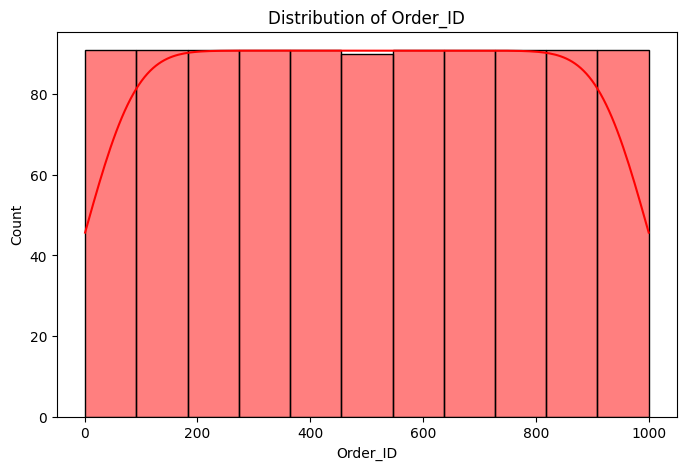

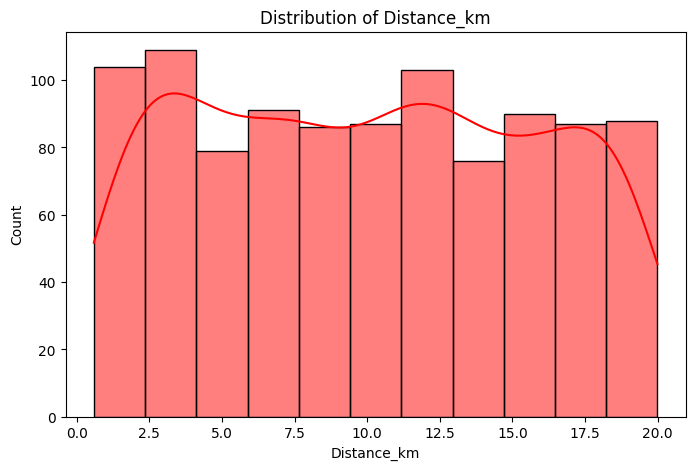

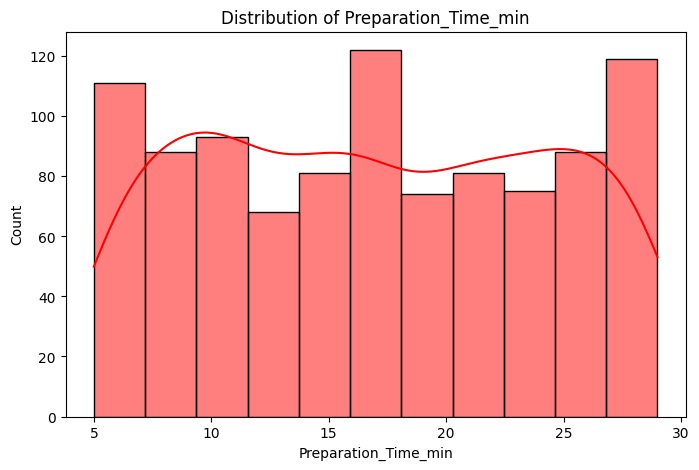

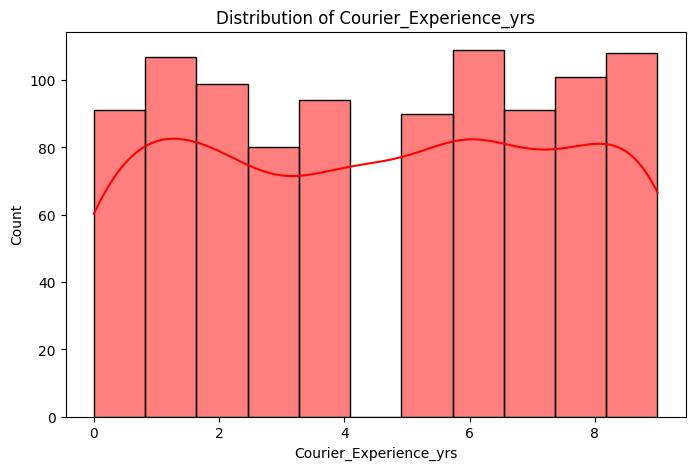

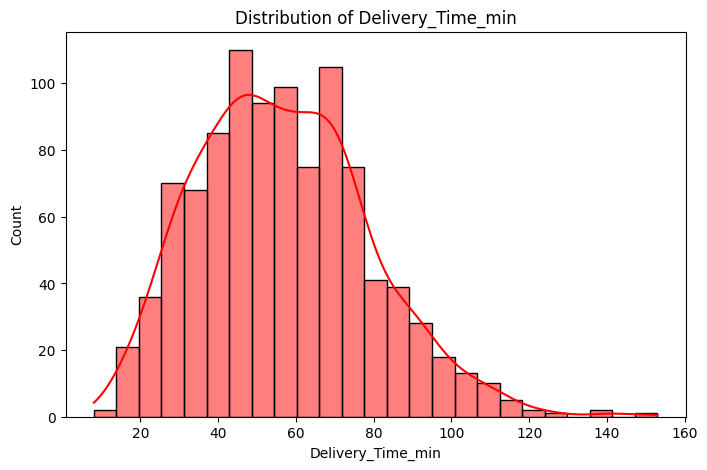

In [17]:
for col in numeric_col:
    distribution_plot(col)

# **Handling Missing Value**

In [18]:
# check for missing value 
print(df.isnull().sum())

print('-'*30)

# check duplicate 
print(df.duplicated().sum())

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64
------------------------------
0


In [20]:
# fill the missing value 

# fill the missing value for weather column
df['Weather'].fillna(df['Weather'].mode()[0], inplace=True)

# fill the missing value for traffic level
df['Traffic_Level'].fillna(df['Traffic_Level'].mode()[0], inplace=True)

# fill the missing value for time of day
df['Time_of_Day'].fillna(df['Time_of_Day'].mode()[0], inplace=True)

# fill the missing value for courier experience with median
df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median(), inplace=True)

# check again for the missing value after fill
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

# **Bivariate Analysis (Feature vs Target)**

**1. Distance vs Delivery Time**

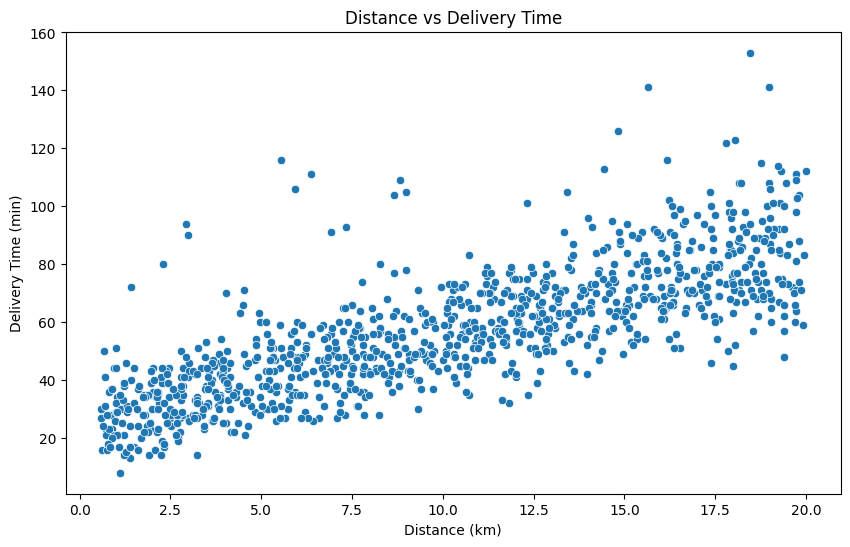

In [21]:
# Distance vs Delivery time with scatter plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Distance_km', y='Delivery_Time_min')
plt.title('Distance vs Delivery Time')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (min)')
plt.show() 

**Insight**

- There is a clear trend showing that the longer the delivery distance, the longer the delivery time.
- The data points form a straight line that slopes upward to the right.


**2. Weather vs Delivery Time**

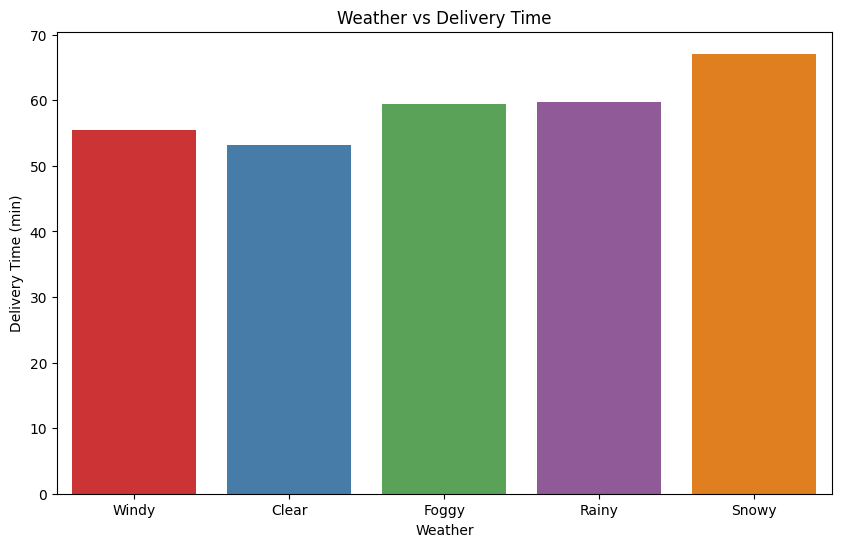

Weather
Clear    53.2
Foggy    59.5
Rainy    59.8
Snowy    67.1
Windy    55.5
Name: Delivery_Time_min, dtype: float64


In [27]:
# weather vs Delivery Time
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Weather', y='Delivery_Time_min', palette='Set1',ci=None)
plt.title('Weather vs Delivery Time')
plt.xlabel('Weather')
plt.ylabel('Delivery Time (min)')
plt.show()

print(df.groupby('Weather')['Delivery_Time_min'].mean().round(1))

**Insight**

- kondisi extreme memperlambat waktu pengiriman 
- **Clear** menjadi cuaca yang memberikan waktu pengiriman yang paling cepat, karena tidak adanya hambatan yang terjadi 
- **windy** tidak terlalu memberikan dampak yang cukup besar, namun tetap lebih lambat dari cuaca clear
- kondisi cuaca **snowy** memberikan dampak yang cukup besar, yang dimana waktu pengiriman menjadi lebih lama.
- **Foggy** dan **Rainy** memberikan dampak yang cukup mirip, yang dimana waktu pengiriman terdapat pada rentang waktu 50-60 menit


**3. Traffic Level vs Delivery Time**

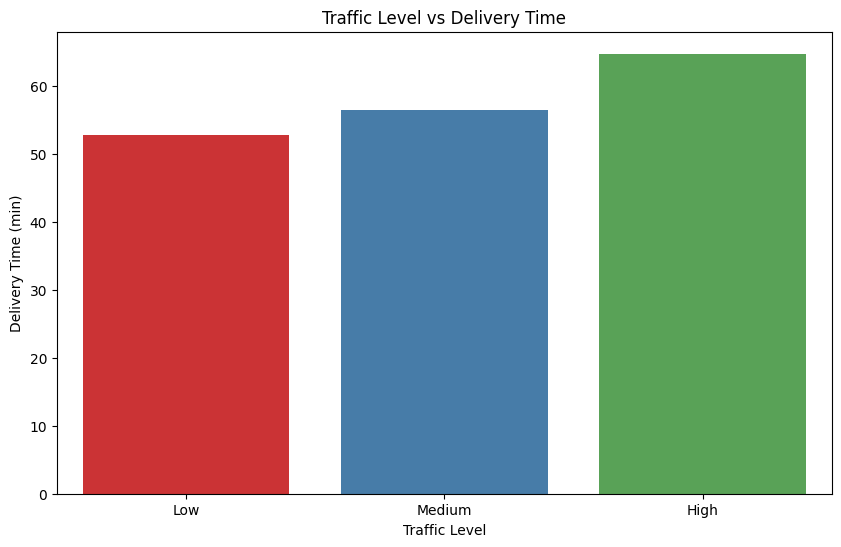

Traffic_Level
High      64.8
Low       52.9
Medium    56.5
Name: Delivery_Time_min, dtype: float64


In [29]:
# traffic level vs delivery time
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Traffic_Level', y='Delivery_Time_min', palette='Set1',ci=None)
plt.title('Traffic Level vs Delivery Time')
plt.xlabel('Traffic Level')
plt.ylabel('Delivery Time (min)')
plt.show()

print(df.groupby('Traffic_Level')['Delivery_Time_min'].mean().round(1))

**Insight**

- Traffic Level Low memberikan waktu pengiriman yang lebih cepat, ini sesuai dengan kondisi yang ada di jalan.
- Traffic Level Medium memberikan waktu pengiriman yang tidak cepat namun tidak juga lambat
- Traffic Level High memberikan waktu pengiriman yang lebih lama, ini sesuai dengan kondisi yang ada di jalan.

**4.Time of Day vs Delivery Time**

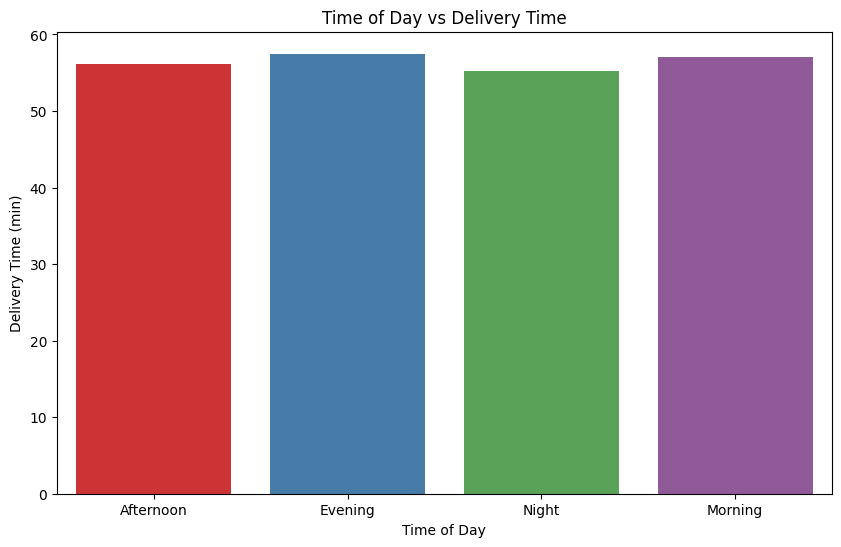

Time_of_Day
Afternoon    56.1
Evening      57.5
Morning      57.0
Night        55.2
Name: Delivery_Time_min, dtype: float64


In [32]:
# time of day vs delivery time
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Time_of_Day', y='Delivery_Time_min', palette='Set1',ci=None)
plt.title('Time of Day vs Delivery Time')
plt.xlabel('Time of Day')
plt.ylabel('Delivery Time (min)')
plt.show()

print(df.groupby('Time_of_Day')['Delivery_Time_min'].mean().round(1))

**Insight**

- Moring dan afternoon memberikan waktu pengiriman yang stabil hal ini bisa terjadi karena merupakan waktu yang dimana tidak sedikit dan tidak banyak order makanan yang masuk, dan kondisi jalan yang tidak terlalu padat
- Evening memberikan waktu pengiriman yang paling lama karena merupakan waktu rush hour, yang memadati jalan
- Night memberikan waktu pengriman yang lebih cepat karena jalanan yang lebih sepi dan tidak padat



**5. Vehicle Type vs Delivery Time**

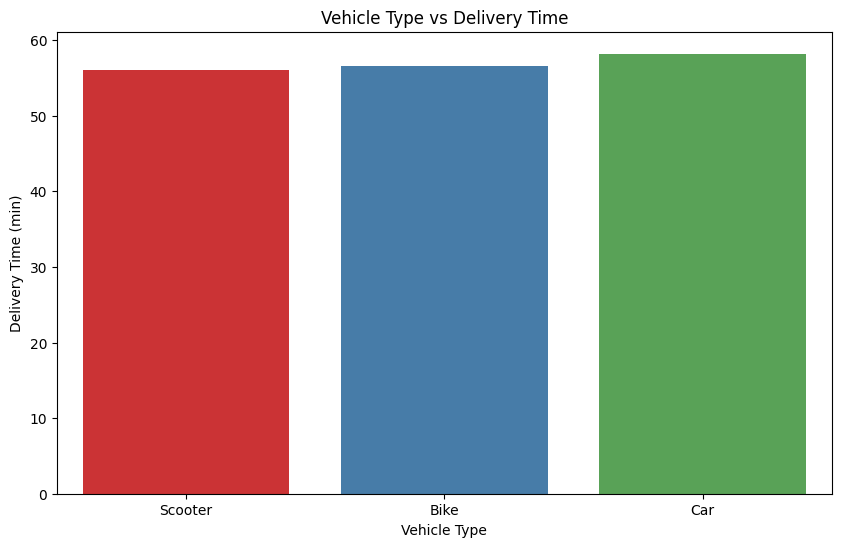

Vehicle_Type
Bike       56.57
Car        58.20
Scooter    56.05
Name: Delivery_Time_min, dtype: float64


In [36]:
# vehicle type vs delivery time
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Vehicle_Type', y='Delivery_Time_min', palette='Set1',ci=None)
plt.title('Vehicle Type vs Delivery Time')
plt.xlabel('Vehicle Type')
plt.ylabel('Delivery Time (min)')
plt.show()

print(df.groupby('Vehicle_Type')['Delivery_Time_min'].mean().round(2))

**Insight**

- **Scooter** menjadi kendaraan yang memakan waktu yang lebih cepat dibanding dengan kendaraan lain, namun jika dibandingkan dengan **Bike** tidak ada perbedaan waktu yang signifikan berbeda
- **Car** menjadi kendaraan yang memekan waktu paling lamban dibandingkan dengan kendaraan lain, hal ini haren kondisi jalan, ukuran, dan juga jumlah orderan makanan 

**6. Preparation Time vs Delivery Time**

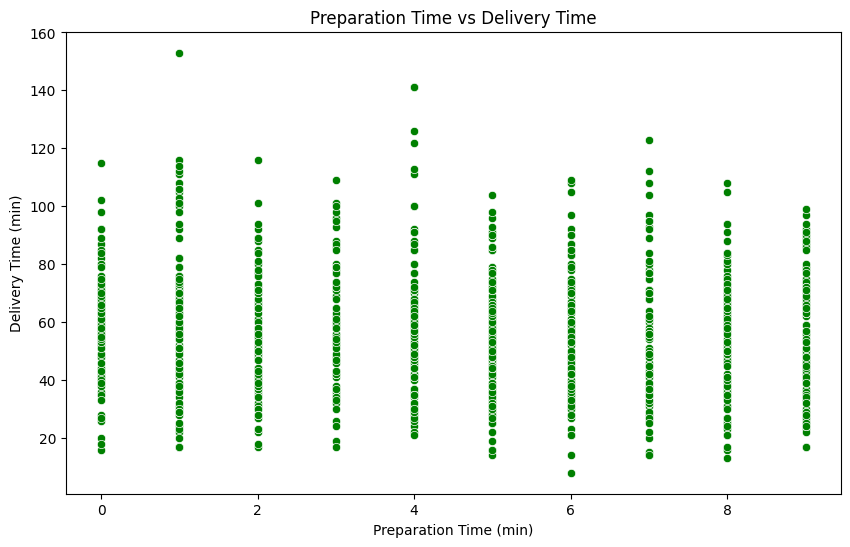

Courier_Experience_yrs
0.0    60.23
1.0    60.49
2.0    54.37
3.0    60.28
4.0    59.60
5.0    54.30
6.0    56.54
7.0    54.85
8.0    53.99
9.0    54.16
Name: Delivery_Time_min, dtype: float64


In [42]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Courier_Experience_yrs', y='Delivery_Time_min', color='green')
plt.title('Preparation Time vs Delivery Time')
plt.xlabel('Preparation Time (min)')
plt.ylabel('Delivery Time (min)')
plt.show()

print(df.groupby('Courier_Experience_yrs')['Delivery_Time_min'].mean().round(2))

**Insight**

- Tidak ada korelasi antara lama pengalaman seorang kurir dengan waktu pengiriman, hal ini terjadi karena, banyak sekali faktor yang lebih kuat seperti, kondisi jalan, cuaca dan kendaraan yang digunakan

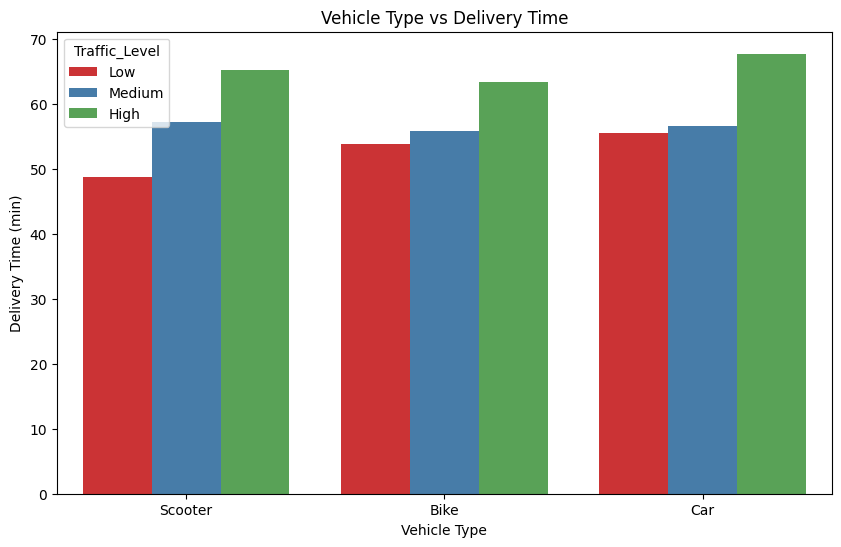

In [25]:
# vehicle type vs delivery time vs traffic level

plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Vehicle_Type', y='Delivery_Time_min', hue='Traffic_Level', palette='Set1',ci=None)
plt.title('Vehicle Type vs Delivery Time')
plt.xlabel('Vehicle Type')
plt.ylabel('Delivery Time (min)')
plt.show()

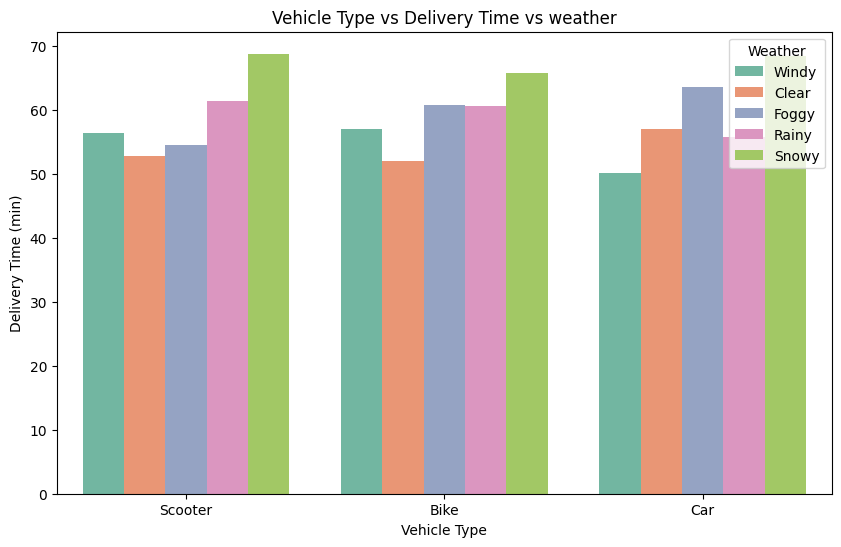

In [50]:
# vehicle type vs delivery time vs traffic level

plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Vehicle_Type', y='Delivery_Time_min', hue='Weather', palette='Set2',ci=None)
plt.title('Vehicle Type vs Delivery Time vs weather')
plt.xlabel('Vehicle Type')
plt.ylabel('Delivery Time (min)')
plt.show()

**Insight**

- **scooter** memiliki waktu pengiriman tercepat saat kondisi cuaca sedang **clear** dan memiliki waktu yang lambat saat kondisi cuaca sedang **Snowy**

- **Bike** memiliki waktu pengiriman tercepat saat kondisi cuaca sedang **Clear** dan memiliki waktu terlambat saat kondisi cuaca sedang **Snowy**. Namun terdapat hal menarik dimana saat kondisi **Foggy** dan **Rainy** ini memiliki perbedaan waktu yang tidak terlalu jauh/ hampir mirip

- **Car** memiliki waktu pengiriman tercepat saat kondisi cuaca sedang **Windy** dan memiliki waktu yang lambat saat kondisi cuaca sedang **Snowy**. Hal ini bsia terjadi karena kondisi jalan yang tidak padat karena cuaca angin yang berdampak berukarangnya waktu pengiriman

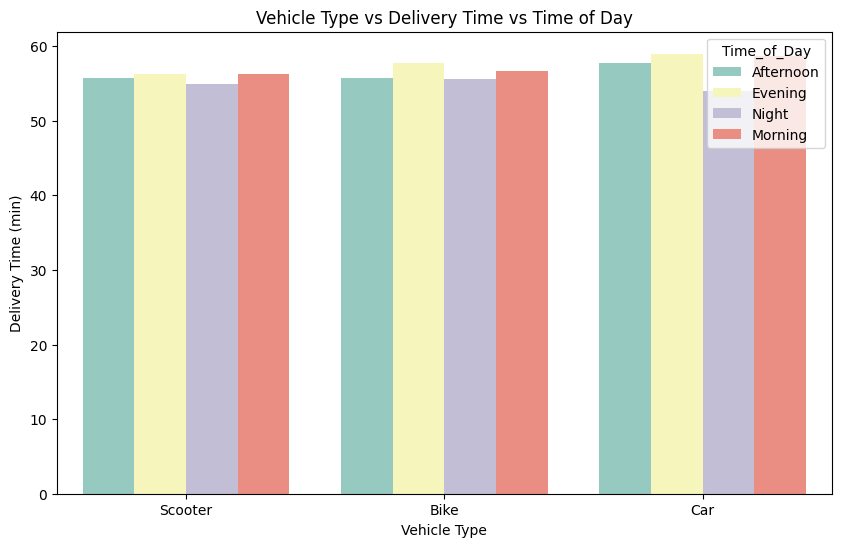

In [53]:
# vehicle type vs delivery time vs time of day

plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Vehicle_Type', y='Delivery_Time_min', hue='Time_of_Day', palette='Set3',ci=None)
plt.title('Vehicle Type vs Delivery Time vs Time of Day')
plt.xlabel('Vehicle Type')
plt.ylabel('Delivery Time (min)')
plt.show()

**Insight**

- Tidak ada perbedaan waktu yang sangat signifikan antara **Bike** dan **scooter**, namun scooter menjadi kendaraan yang memiliki waktu pengiriman yang paling cepat daripada yang lain 

- **Car** menjadi kendaraan yang memiliki waktu pengiriman terlama, namun pada malah hari, **Car** menjadi kendaraan yang memiliki wakut pengiriman paling cepat di antara yang lain

# **Multivariate Analysis (Before Encoding)**

**Heatmap for numeric col**

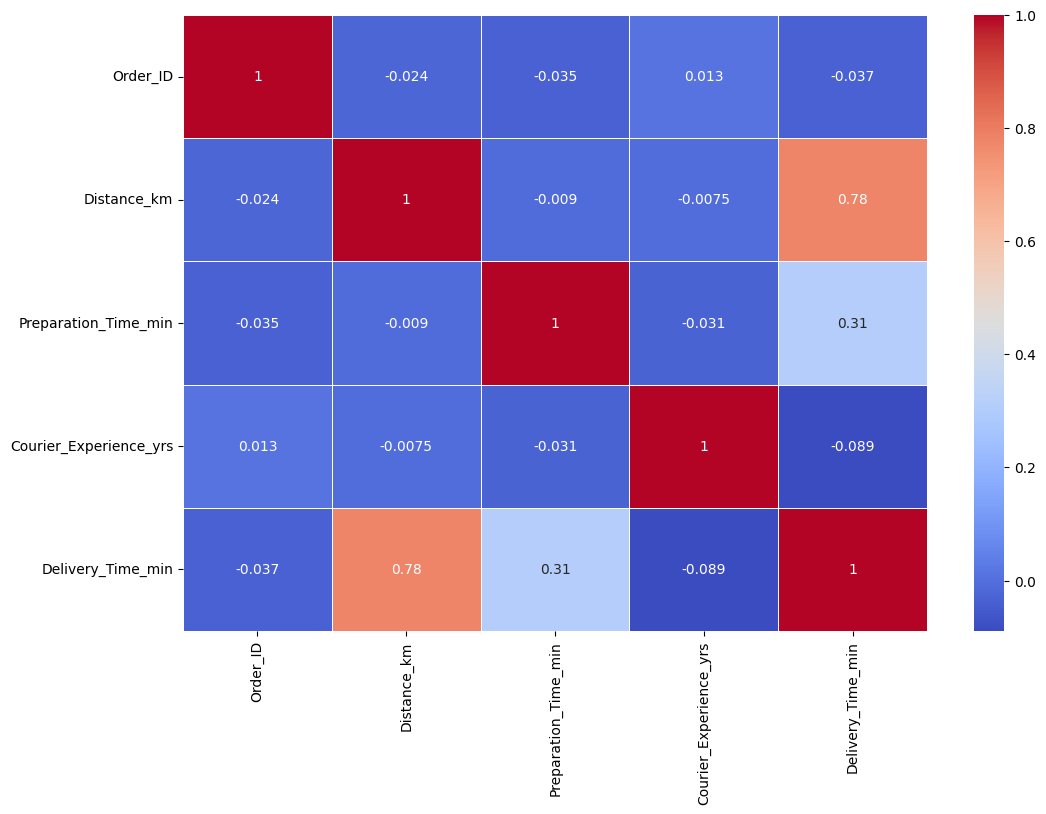

In [59]:
# make a correlation heatmap for numeric col
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_col].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

**Heatmap for target delivery time**

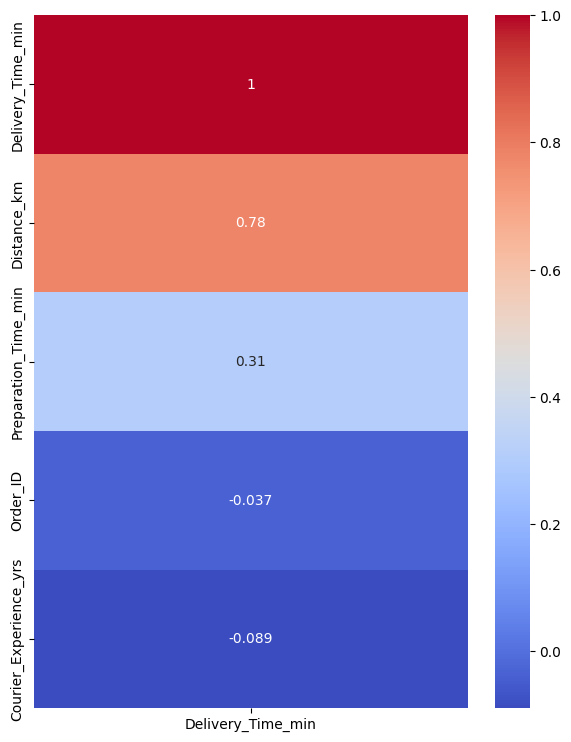

In [60]:
# make heatmap for target delivery time
plt.figure(figsize=(7,9))
sns.heatmap(df[numeric_col].corr()['Delivery_Time_min'].sort_values(ascending=False).to_frame(), annot=True, cmap='coolwarm')
plt.show()

# **Business Question**

**1. Do weather conditions and traffic levels have a significant impact on delivery times?**

Traffic_Level   Low  Medium  High
Weather                          
Clear          49.9    54.2  57.2
Foggy          53.3    63.0  67.2
Rainy          55.0    55.1  77.0
Snowy          61.9    71.7  70.9
Windy          51.4    53.8  63.5


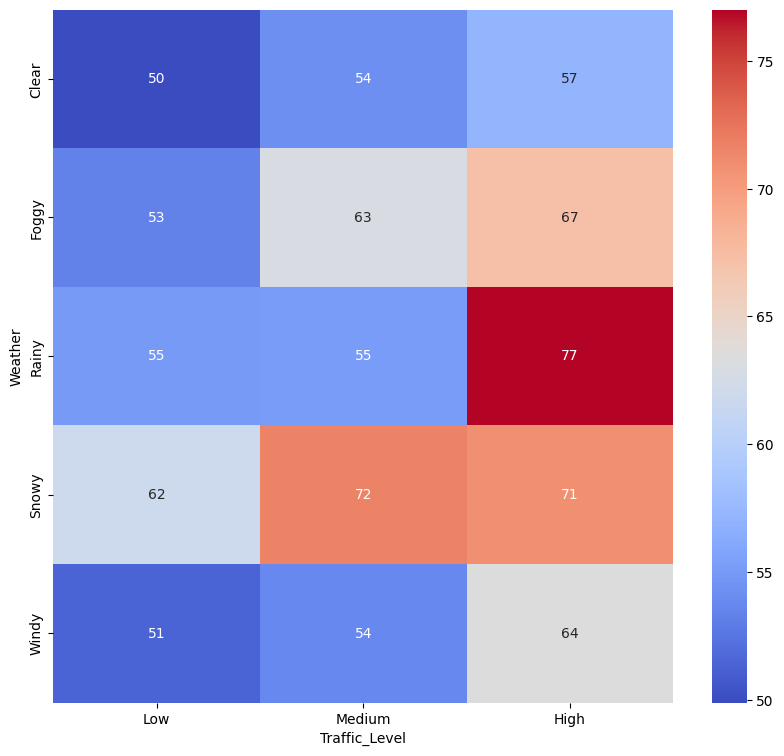

In [63]:
# pivot table for weather vs traffic level vs delivery time
pivot_table = df.pivot_table(index='Weather', columns='Traffic_Level', values='Delivery_Time_min', aggfunc='mean').round(1)
pivot_table = pivot_table[['Low','Medium','High']]
print(pivot_table)

# make heatmap for pivot table
plt.figure(figsize=(10,9))
sns.heatmap(pivot_table, annot=True, cmap='coolwarm')
plt.show()

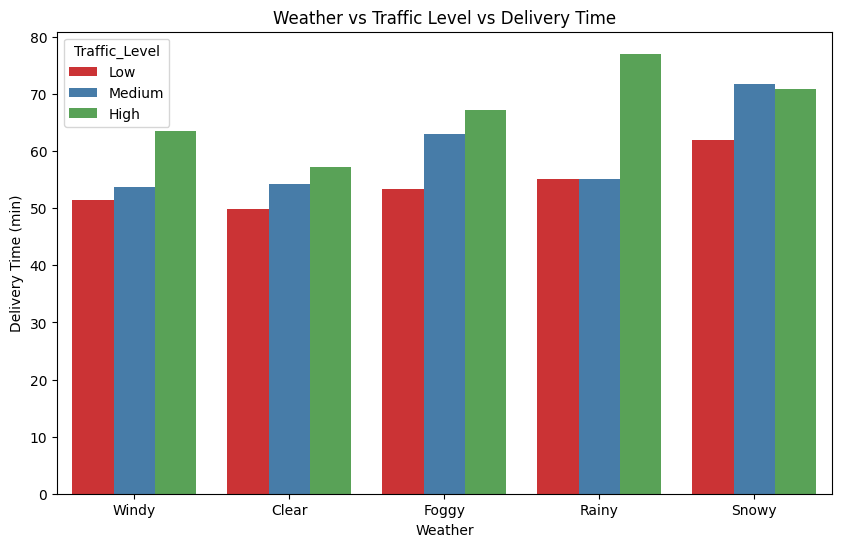

In [31]:
## make barplot for weather vs traffic level vs delivery time
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Weather', y='Delivery_Time_min', hue='Traffic_Level', palette='Set1', ci=None)
plt.title('Weather vs Traffic Level vs Delivery Time')
plt.xlabel('Weather')
plt.ylabel('Delivery Time (min)')
plt.show()

**2. How does efficiency compare by vehicle type?**

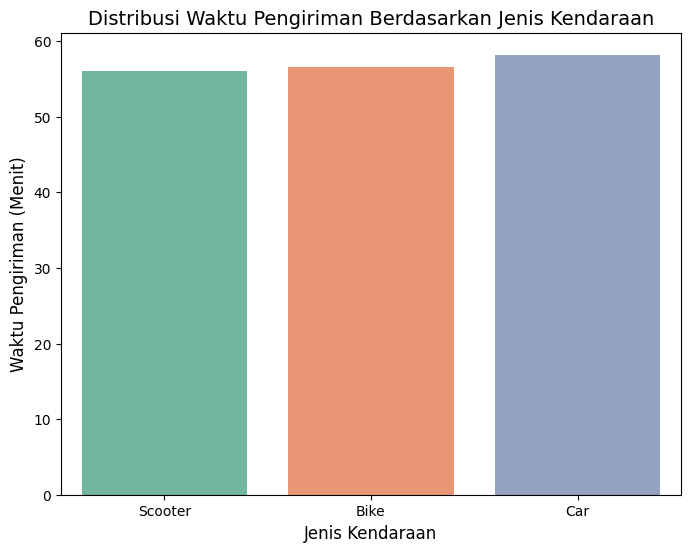

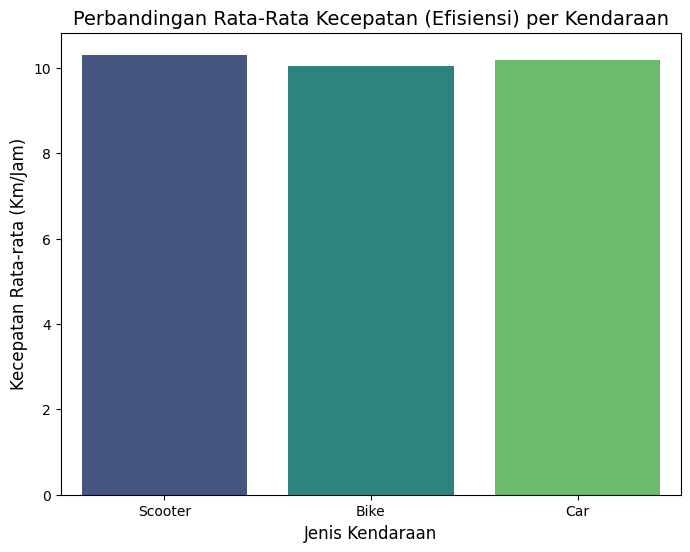

In [33]:
# vehicle type vs delivery time with barplot
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='Vehicle_Type', y='Delivery_Time_min', palette='Set2', errorbar=None)
plt.title('Distribusi Waktu Pengiriman Berdasarkan Jenis Kendaraan', fontsize=14)
plt.xlabel('Jenis Kendaraan', fontsize=12)
plt.ylabel('Waktu Pengiriman (Menit)', fontsize=12)
plt.show()

# create new column for speed
# Distance / (Time in minutes)
df['Speed_kmh'] = df['Distance_km'] / (df['Delivery_Time_min'] / 60)

# Menampilkan rata-rata kecepatan dengan Barplot
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='Vehicle_Type', y='Speed_kmh', errorbar=None, palette='viridis')
plt.title('Perbandingan Rata-Rata Kecepatan (Efisiensi) per Kendaraan', fontsize=14)
plt.xlabel('Jenis Kendaraan', fontsize=12)
plt.ylabel('Kecepatan Rata-rata (Km/Jam)', fontsize=12)
plt.show()

**3. When is the busiest time of day that results in the longest delivery times? Are there any specific patterns between the afternoon and the evening?**

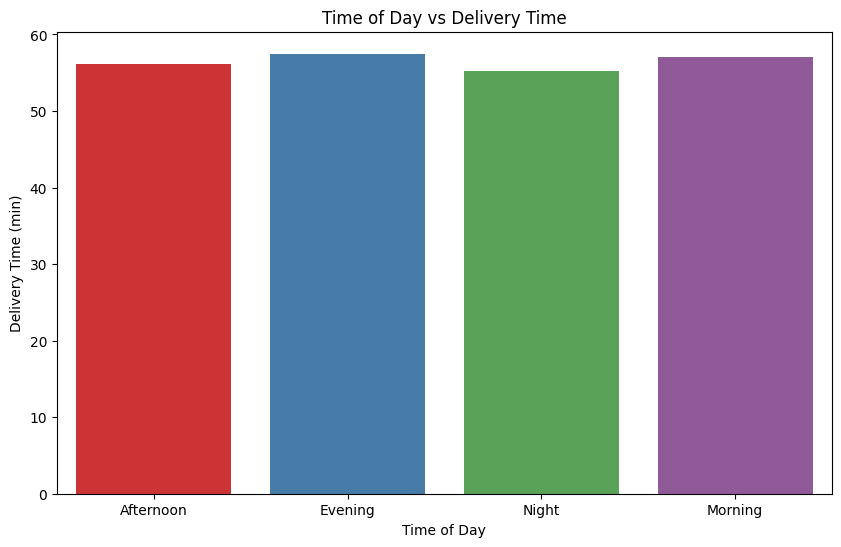

Time_of_Day
Afternoon    56.1
Evening      57.5
Morning      57.0
Night        55.2
Name: Delivery_Time_min, dtype: float64

In [37]:
# time of day vs delivery time
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Time_of_Day', y='Delivery_Time_min', palette='Set1',ci=None)
plt.title('Time of Day vs Delivery Time')
plt.xlabel('Time of Day')
plt.ylabel('Delivery Time (min)')
plt.show()

df.groupby('Time_of_Day')['Delivery_Time_min'].mean().round(1)

# **Encoding**

In [ ]:
# import libraries
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder

# encode the ordinal columns
ordinal_col = {
    'Traffic_Level': ['Low','Medium','High']
}

# 
encoder = OrdinalEncoder(categories=list(ordinal_col.values()))

df[list(ordinal_col.keys())] = encoder.fit_transform(df[list(ordinal_col.keys())])

In [ ]:
# encode the nominal columns
df=pd.get_dummies(df, columns=nominal_col, drop_first=True)

In [ ]:
# show data after encoding
df.head()

,Order_ID,Distance_km,Traffic_Level,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7.93,0.0,12,1.0,43,False,False,False,True,False,False,False,False,True
1,738,16.42,1.0,20,2.0,84,False,False,False,False,True,False,False,False,False
2,741,9.52,0.0,28,1.0,59,True,False,False,False,False,False,True,False,True
3,661,7.44,1.0,5,1.0,37,False,True,False,False,False,False,False,False,True
4,412,19.03,0.0,16,5.0,68,False,False,False,False,False,True,False,False,False


**Heatmap after encoding**

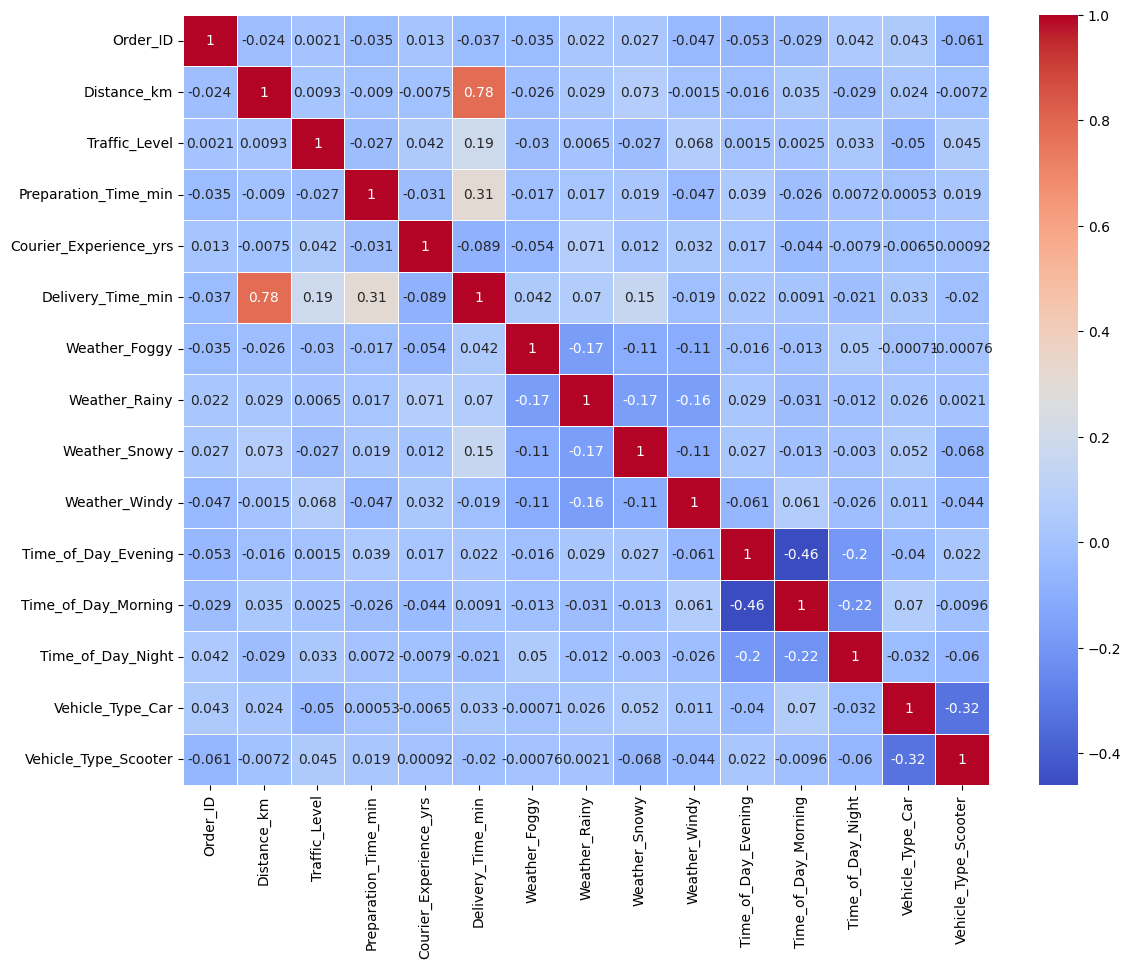

In [ ]:
# make a correlation heatmap for all feature after encoding
plt.figure(figsize=(13,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

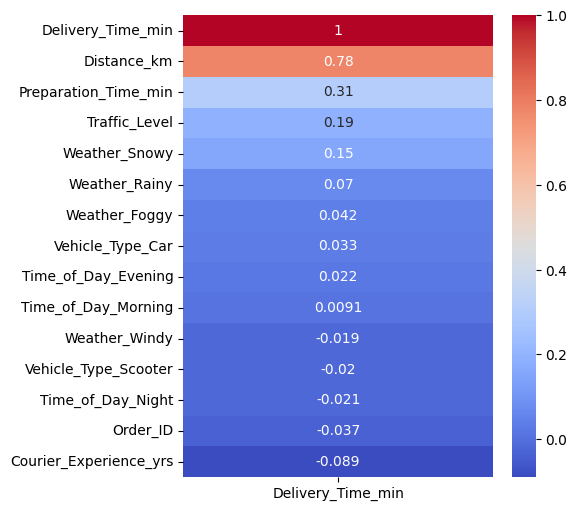

In [ ]:
# heatmap target delivery time
plt.figure(figsize=(5,6))
sns.heatmap(df.corr()['Delivery_Time_min'].sort_values(ascending=False).to_frame(), annot=True, cmap='coolwarm')
plt.show()

**Insight**

- jarak pengiriman merupakan faktor yang memiliki korelasi yang tinggi, hal ini menunjukan bahwa semakin jauh jarak maka semakin lama waktu pengiriman

- Preparation, atau waktu persiapan makanan menjadi faktor kedua yang memiliki korelasi tinggi, terlihat bahwa skor menujukan angka **0.40**

